In [ ]:
import gdown

gdown.download('https://bit.ly/3736JW1', 'ns_book6.csv', quiet=False)

Downloading...
From: https://bit.ly/3736JW1
To: /content/ns_book6.csv
100%|██████████| 55.0M/55.0M [00:00<00:00, 254MB/s]


'ns_book6.csv'

In [ ]:
import pandas as pd

ns_book6 = pd.read_csv('ns_book6.csv', low_memory=False)
ns_book6.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021.0,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021.0,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021.0,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021.0,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021.0,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


In [ ]:
ns_book6.describe()

,번호,발행년도,도서권수,대출건수
count,379976.000000,379976.000000,379976.000000,379976.000000
mean,201726.332847,2008.516306,1.135874,11.504629
std,115836.454596,8.780529,0.483343,19.241926
min,1.000000,1947.000000,0.000000,0.000000
25%,102202.750000,2003.000000,1.000000,2.000000
50%,203179.500000,2009.000000,1.000000,6.000000
75%,301630.250000,2015.000000,1.000000,14.000000
max,401681.000000,2650.000000,40.000000,1765.000000


dfscribe() 메서드는 기본적으로 수치형 열에 대한 요약 통계를 보여줌
- count
- mean
- std
- min
- 50%
- 25%와 75% 순서대로 늘어놓았을 때 25% 지점과 75% 지점에 놓인 값
- max

도서의 최솟값이 0
-> 도서가 없는데 왜 대출 데이터에 포함되어 있지?

이유는 모르지만 이런 도서가 많으면이를 걸러내야 할지 고려해야함

3장에서 했던 것 처럼 불리언 배열와 sum()함수를 활용

In [ ]:
sum(ns_book6['도서권수']==0)

3206

3천개가 넘는 도서가 0개이다.
전체 데이터에 비하면 1%%가 채 안되기 때문에 무시할만한 수치이다.

하지만 이런 도서가 꽤 많다면 어떤 이유에서 0권인지, 이를 분석에서 제외할지 판단해야 한다.

처리 기준은 해결할 문제에 따라 다르며 이런한 결정이 분석 결과에 큰 영향을 미칠 수도 있다

이 책에서는 실제로 없는 도서 대출 데이터는 의미가 없다고 생각하여 다음과 같이 제외하겠따

In [ ]:
ns_book7 = ns_book6[ns_book6['도서권수']>0]

다시 기술 통계를 출력해보자

describe()메서드는 기본적으로 25%, 50%, 75%에 위치한 값을 보여주지만 원하는 위치를 보고싶으면 percentiles매개변수에 위치를 지정하면 된다

In [ ]:
ns_book7.describe(percentiles=[0.3, 0.6, 0.9])

,번호,발행년도,도서권수,대출건수
count,376770.000000,376770.000000,376770.000000,376770.000000
mean,202977.476649,2008.460076,1.145540,11.593439
std,115298.245784,8.773148,0.473853,19.279409
min,1.000000,1947.000000,1.000000,0.000000
30%,124649.700000,2004.000000,1.000000,2.000000
50%,204550.500000,2009.000000,1.000000,6.000000
60%,243537.400000,2011.000000,1.000000,8.000000
90%,361341.100000,2018.000000,2.000000,28.000000
max,401681.000000,2650.000000,40.000000,1765.000000


열의 데이터 타입이 수치가 아닌 다른 데이터 타입의 열의 기술통계를 보고싶다면 include 매개변수의 데이터 타입을 지정할 수도 있다.

예를 들어 Object 타입의 열에 대한 통계를 보려면 이렇게 쓸 수 있다.

In [ ]:
ns_book7.describe(include='object')

,도서명,저자,출판사,ISBN,세트 ISBN,부가기호,권,주제분류번호,등록일자
count,376770,376770,376770,376770,55866,308252,61793,359792,376770
unique,336408,248850,21875,350810,14875,17,834,12467,4562
top,승정원일기,세종대왕기념사업회 [편],문학동네,9788937430299,9788937460005,0,1,813.6,1970-01-01
freq,250,303,4410,206,702,158235,13282,14816,28185


count 행은 누락된 값을 제외한 데이터 개수를 나타내고, unique 행은 고유한 값의 개수를 나타낸다.

top 행은 가장 많이 등장하는 값
frequ행은 top 행에 등장하는 항목의 빈도수

실행 결과에 따르면 도서명 열에서 가장 많이 등장하는 데이터는 승정원 일기로 250회 등장


이제 평균, 중앙값 등 개발 통계량에 대해 좀 더 알아보자

# 평균

In [ ]:
x = [10, 20, 30]
sum = 0
for i in range(3):
    sum += x[i]
print("평균:", sum / len(x))

평균: 20.0


평균 대출건수

In [ ]:
ns_book7['대출건수'].mean()

np.float64(11.593438968070707)

# 중앙값

In [ ]:
ns_book7['대출건수'].median()

6.0

짝수일 때는 가운데 두 개의 값을 평균하여 중앙값을 결정

In [ ]:
temp_df = pd.DataFrame([1,2,3,4])
temp_df.median()

,0
0,2.5


## 중복값 제거 & 중앙값 구하기

In [ ]:
ns_book7['대출건수'].drop_duplicates().median()

183.0

중복된 값을 제거하니까 중앙값이 높아졌다\
이 결과로 짐작하자면 작은 대출건수에 중복된 행이 많다고 생각할 수 있다.

# 최솟값 최댓값

In [ ]:
ns_book7['대출건수'].min()

0

In [ ]:
ns_book7['대출건수'].max()

1765

# 분위수

분위수는 데이터를 순서대로 놓았을 때 이를 균등한 간격으로 나누는 기준점이다.

이분위수는 전체 데이터를 두 구간으로 나누기 때무에 중앙값에 해당

많이 사용하는 사분위수는 순서대로 정렬된 데이터를 네 구간으로 나눈다.

따라서 사분위수는 3개가 나오고 각각 25%, 50%, 75%에 해당한다

## quantile 메서드

In [ ]:
ns_book7['대출건수'].quantile(0.25)

np.float64(2.0)

In [ ]:
ns_book7['대출건수'].quantile([0.25,0.5,0.75])

,대출건수
0.25,2.0
0.50,6.0
0.75,14.0


1,2,3,4,5 다섯 개의 숫자가 있을 때 90% 위치에 있는 값은 얼마?

In [ ]:
pd.Series([1,2,3,4,5]).quantile(0.9)

np.float64(4.6)

4.6은 어떻게 계산된 값일까?\
quantile은 interpolation 매개변수에서 중간 값을 계산하는 방법을 결정한다

위 코드는 interpolation 매개변수를 따로 지정하지 않아서 기본값으로 계산되었다.

예를 들어 4와 5 사이의 90에 해당하는 분위수를 찾을 때 그림처럼 4의 분위수 0.75와 5의 분위수 1.0.을 사용해 간단한 비례식을 세울 수 있다.

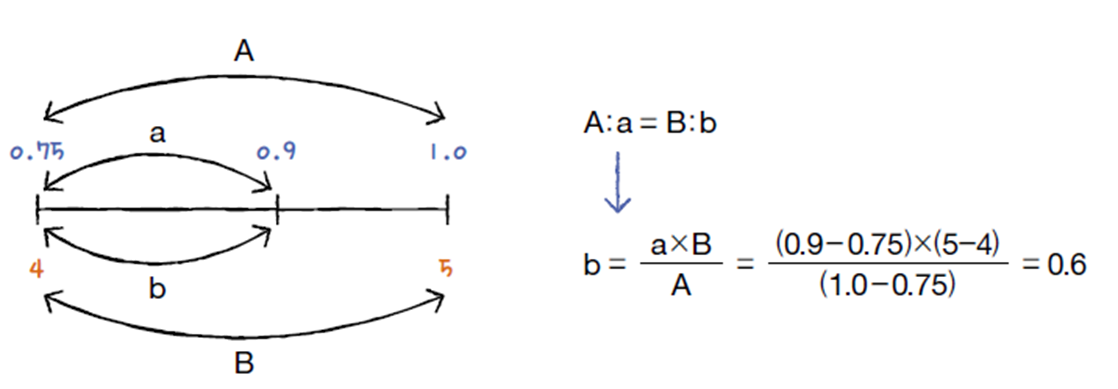


In [ ]:
4 + (0.9-0.75)*(5-4)/(1.0-0.75)

4.6

In [ ]:
pd.Series([1,2,3,4,5]).quantile(0.9,interpolation='midpoint')

np.float64(4.5)

interpolation 매개변수는 linear 외에도 여러 가지 다른 보간 방식을 제공한다.

midporint는 분위수에 상관없이  무조건 두 수 사이의 중앙값을 사용한다

In [ ]:
pd.Series([1,2,3,4,5]).quantile(0.9,interpolation='nearest')

np.int64(5)

'nearest'는 두 수 중에서 가까운 값을 선택
이 경우는 0.9가 1.0에 더 가깝기 때문에 5가 된다.


## 백분위 구하기

남산 도서관 대출 데이터에서 대출건수 10이 위치한 백분위를 어떻게 찾을 수 있을까?



In [ ]:
borrow_10_flag = ns_book7['대출건수'] < 10

borrow_10_flag배열(실제로는 시리즈 객체)에서 True인 개수를 모두 헤아린 후 전체 데이터 개수로 나누면 10보다 작은 대출 건수의 비율을 얻을 수 있다.

In [ ]:
borrow_10_flag.mean()

np.float64(0.6402712530190833)

10에 대한 백분위는 0.65정도가 될 것이다

quantile() 메서드에 백분위를 넣어 직접 확인해보자

In [ ]:
ns_book7['대출건수'].quantile(0.65)

np.float64(10.0)

# 분산

분산 : 평균으로부터 데이터가 얼마나 퍼져있는지를 나타내는 통계량

데이터가 가운데 모여 있다면 분산이 작고 넓게 퍼져있다면 분산이 큼

분산 구하는 방법 : 데이터의 값에서 평균을 뺀 다음 제곱한 후 샘플 개수로 나누어 구함

In [ ]:
ns_book7['대출건수'].var()

371.6956304306922

분산은 데이터가 평균에서 얼마나 퍼져있는지 나타내는 값
-> 결과만 보고 값이 작은지 큰지 판단하기 어려움
& 해석하기 조금 어려움


이를 보완하기 위해 분산에 제곱근을 취한 표준편차를 사용

# 표준편차

분산에 제곱근을 씌운 것

In [ ]:
ns_book7['대출건수'].std()

19.27940949382766

도서대출 건수는 평균 11회가 조금 넘는데 표준편차가 19이다 \
-> 아마 평균보다훨씬 큰 대출건수가 있을 것이디

## 수식으로 코드 구현

판다스와 넘파이를 사용해 표준편차를 수식대로 직접 계산해보자

In [ ]:
import numpy as np

diff = ns_book7['대출건수'] - ns_book7['대출건수'].mean()

np.sqrt( np.sum(diff**2) / (len(ns_book7)-1) )

np.float64(19.279409493785508)

# 최빈값 구하기

최빈값에 대해 알아보자

최빈값은 데이터에서 가장 많이 등장하는 값을 의미한다

앞서 출력한 describe(include='object')의 출력 중에 top행에 나온 값이 바로 최빈값

In [ ]:
ns_book7['도서명'].mode()

,도서명
0,승정원일기


mode는 텍스트 뿐만 아니라 수치형에도 적용할 수 있다

남산도서관 대출 데이터에서 가장 많이 등장하는 년도를 알아보자

In [ ]:
ns_book7['발행년도'].mode()

,발행년도
0,2012.0


# 데이터프레임에서 기술 통계 구하기

앞서 공부한 메서드들은 데이터프레임에도 사용할 수 있다

수치형 열만 연산할 수 있기 때문에 numeric_only 매개변수를 Ture로 지정해야 한다.

만약 numeric_only 매개변수를 지정하지 않으면 모든 데이터 타입의 열에 대해 수행하기 때문에 시간이 오래 걸리고 경고가 발생한다

In [ ]:
ns_book7.mean(numeric_only=True)

,0
번호,202977.476649
발행년도,2008.460076
도서권수,1.145540
대출건수,11.593439


In [ ]:
ns_book7.loc[:, '도서명':].mode()

,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,승정원일기,세종대왕기념사업회 [편],문학동네,2012.0,9788937430299,9788937460005,0,1,813.6,1,0,1970-01-01


도서명 열에서 가장 많이 등장하는 것 : 승정원 일기

출판사 열에서 장 많이 등장하는 값 : 문학 동네

In [ ]:
ns_book7.to_csv('ns_book7.csv', index=False)

------

# 넘파이의 기술통계 함수

## 평균 구하기

In [ ]:
import numpy as np

np.mean(ns_book7['대출건수'])

np.float64(11.593438968070707)

In [ ]:
np.average(ns_book7['대출건수'], weights=1/ns_book7['도서권수'])

np.float64(10.543612175385386)

In [ ]:
np.mean(ns_book7['대출건수']/ns_book7['도서권수'])

np.float64(9.873029861445774)

In [ ]:
ns_book7['대출건수'].sum()/ns_book7['도서권수'].sum()

np.float64(10.120503701300958)

# 중앙값 구하기

In [ ]:
np.median(ns_book7['대출건수'])

np.float64(6.0)

# 최솟값, 최댓값 구하기

In [ ]:
np.min(ns_book7['대출건수'])

0

In [ ]:
np.max(ns_book7['대출건수'])

1765

# 분위수 구하기

In [ ]:
# interpolation 매개변수가 numpy 1.22(python >= 3.8) 버전부터 method로 바뀜
np.quantile(ns_book7['대출건수'], [0.25,0.5,0.75])

array([ 2.,  6., 14.])

# 분산 구하기

In [ ]:
np.var(ns_book7['대출건수'])

371.694643898775

In [ ]:
ns_book7['대출건수'].var(ddof=0)

371.694643898775

In [ ]:
np.var(ns_book7['대출건수'], ddof=1)

371.6956304306922

# 표준편자 구하기

In [ ]:
np.std(ns_book7['대출건수'])

19.279383908693113

#최빈값 구하기

In [ ]:
values, counts = np.unique(ns_book7['도서명'], return_counts=True)
max_idx = np.argmax(counts)
values[max_idx]

'승정원일기'

# 확인 문제

4.

In [ ]:
ns_book7[['출판사','대출건수']].groupby('출판사').mean().sort_values('대출건수', ascending=False).head(10)

,대출건수
출판사,
동녁라이프,224.000000
와이비엠시사,215.000000
환상,210.000000
두앤비컨텐츠(랜덤하우스중앙),167.000000
개미들출판사-에셀문화사,157.000000
해커스 어학 연구소,149.500000
Test clinic,137.000000
마야출판사,133.333333
해밀 & Co.,133.000000


5.

In [ ]:
target_range = np.array(ns_book7['대출건수'].quantile(q=[0.25,0.75]))
target_bool_idx = (ns_book7['대출건수'] >= target_range[0]) & (ns_book7['대출건수'] <= target_range[1])
target_bool_idx.sum()/len(ns_book7)*100

np.float64(51.51737134060568)